In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from xgboost import XGBRegressor

df = pd.read_csv('power_trading_demand_data_2025.csv')
df

,Unnamed: 0,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,...,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor,is_demand_outlier
0,0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,...,NaN,NaN,19918.000000,5405,0.271363,14513,NaN,NaN,NaN,False
1,1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,...,NaN,NaN,20042.500000,5358,0.265682,14809,249.0,21368.0,0.651909,False
2,2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,...,19918.0,NaN,20137.666667,5237,0.257625,15091,161.0,22683.0,0.615470,False
3,3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,...,20167.0,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0,0.629484,False
4,4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,...,20328.0,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0,0.614771,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,17515,2025-12-31 21:30:00,44,28633,30690,26868,3994,6606,0,22126,...,29072.0,29056.0,28162.041667,3994,0.148653,22874,-1028.0,NaN,NaN,False
17516,17516,2025-12-31 22:00:00,45,27381,30212,25722,4027,6606,0,22126,...,27896.0,27917.0,28116.312500,4027,0.156559,21695,-1146.0,NaN,NaN,False
17517,17517,2025-12-31 22:30:00,46,26563,29786,25049,4059,6606,0,22126,...,26868.0,26598.0,28084.041667,4059,0.162042,20990,-673.0,NaN,NaN,False
17518,17518,2025-12-31 23:00:00,47,25481,30558,23955,4115,6606,0,22126,...,25722.0,25493.0,28052.000000,4115,0.171780,19840,-1094.0,NaN,NaN,False


In [3]:
df.drop('Unnamed: 0', axis='columns', inplace=True)

In [11]:
# predicting peak demand (yes/no) - a classification problem

# we create a 'peak' column that holds 1 if >= 90th percentile of demand, otherwise 0

peak_value = df['england_wales_demand'].quantile(0.9) # 32784.4


def is_peak_demand(demand):
    if demand >= peak_value:
        return 1
    else:
        return 0

df['is_peak_demand'] = df['england_wales_demand'].apply(is_peak_demand)

df.head(50)

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor,is_demand_outlier,is_peak_demand
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,NaN,19918.000000,5405,0.271363,14513,NaN,NaN,NaN,False,0
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,NaN,20042.500000,5358,0.265682,14809,249.0,21368.0,0.651909,False,0
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,NaN,20137.666667,5237,0.257625,15091,161.0,22683.0,0.615470,False,0
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0,0.629484,False,0
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0,0.614771,False,0
5,2025-01-01 02:30:00,6,19214,24562,18248,5044,6606,0,19270,0,...,NaN,19462.500000,5044,0.276414,13204,-406.0,25869.0,0.615238,False,0
6,2025-01-01 03:00:00,7,18874,24258,17855,4972,6606,0,19270,0,...,NaN,19232.857143,4972,0.278465,12883,-393.0,25538.0,0.603039,False,0
7,2025-01-01 03:30:00,8,18448,24015,17367,4900,6606,0,19270,0,...,NaN,18999.625000,4900,0.282144,12467,-488.0,26378.0,0.587778,False,0
8,2025-01-01 04:00:00,9,17844,24100,16774,4815,6606,0,19270,0,...,NaN,18752.333333,4815,0.287051,11959,-593.0,27109.0,0.572154,False,0
9,2025-01-01 04:30:00,10,17545,23924,16489,4730,6606,0,19270,0,...,NaN,18526.000000,4730,0.286858,11759,-285.0,29311.0,0.567122,False,0


In [13]:
df['is_peak_demand'].value_counts()

is_peak_demand
0    15768
1     1752
Name: count, dtype: int64

In [15]:
newdf = df.drop(['england_wales_demand', 'nd', 'tsd', 'net_demand', 'is_morning_peak', 'is_evening_peak', 'demand_change_30m', 'daily_spread', 'load_factor', 'is_demand_outlier', 'embedded_wind_generation', 'embedded_solar_generation', 'renewable_gen', 'renewable_pct', 'pump_storage_pumping', 'ifa_flow', 'viking_flow', 'timestamp', 'day_of_week'], axis='columns')
newdf.head()

,settlement_period,embedded_wind_capacity,embedded_solar_capacity,non_bm_stor,scottish_transfer,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,...,quarter,weekday,week_number,is_weekend,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,is_peak_demand
0,1,6606,19270,0,6353,-1026,1,-232,-386,-558,...,1,2,1,False,True,NaN,NaN,NaN,19918.000000,0
1,2,6606,19270,0,6333,-1023,1,-124,-282,-564,...,1,2,1,False,True,19918.0,NaN,NaN,20042.500000,0
2,3,6606,19270,0,6380,-922,1,-119,-384,-205,...,1,2,1,False,True,20167.0,19918.0,NaN,20137.666667,0
3,4,6606,19270,0,6250,-915,0,-119,-334,-193,...,1,2,1,False,True,20328.0,20167.0,NaN,19968.250000,0
4,5,6606,19270,0,6142,-899,0,-119,-363,-622,...,1,2,1,False,True,19460.0,20328.0,NaN,19705.400000,0


In [27]:
newdf.drop(['nsl_flow', 'eleclink_flow', 'greenlink_flow'], axis='columns', inplace=True)
newdf.head()

,settlement_period,embedded_wind_capacity,embedded_solar_capacity,day,month,year,hour,minute,quarter,weekday,week_number,is_weekend,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,is_peak_demand
0,1,6606,19270,1,1,2025,0,0,1,2,1,False,True,NaN,NaN,NaN,19918.000000,0
1,2,6606,19270,1,1,2025,0,30,1,2,1,False,True,19918.0,NaN,NaN,20042.500000,0
2,3,6606,19270,1,1,2025,1,0,1,2,1,False,True,20167.0,19918.0,NaN,20137.666667,0
3,4,6606,19270,1,1,2025,1,30,1,2,1,False,True,20328.0,20167.0,NaN,19968.250000,0
4,5,6606,19270,1,1,2025,2,0,1,2,1,False,True,19460.0,20328.0,NaN,19705.400000,0


In [31]:
# filling na values and converting strings/bools to numbers

newdf['lagged_demand_30m'] = newdf['lagged_demand_30m'].fillna(newdf['lagged_demand_30m'].mean())
newdf['lagged_demand_1h'] = newdf['lagged_demand_1h'].fillna(newdf['lagged_demand_1h'].mean())
newdf['lagged_demand_24h'] = newdf['lagged_demand_24h'].fillna(newdf['lagged_demand_24h'].mean())

def is_weekend_to_value(day):
    if day == True:
        return 1
    else:
        return 0

newdf['is_weekend'] = newdf['is_weekend'].apply(is_weekend_to_value)

def night_to_value(night):
    if night == True:
        return 1
    else:
        return 0

newdf['night'] = newdf['night'].apply(night_to_value)

newdf.head(20)

,settlement_period,embedded_wind_capacity,embedded_solar_capacity,day,month,year,hour,minute,quarter,weekday,week_number,is_weekend,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,is_peak_demand
0,1,6606,19270,1,1,2025,0,0,1,2,1,0,1,23996.265712,23996.268067,23985.146635,19918.000000,0
1,2,6606,19270,1,1,2025,0,30,1,2,1,0,1,19918.000000,23996.268067,23985.146635,20042.500000,0
2,3,6606,19270,1,1,2025,1,0,1,2,1,0,1,20167.000000,19918.000000,23985.146635,20137.666667,0
3,4,6606,19270,1,1,2025,1,30,1,2,1,0,1,20328.000000,20167.000000,23985.146635,19968.250000,0
4,5,6606,19270,1,1,2025,2,0,1,2,1,0,1,19460.000000,20328.000000,23985.146635,19705.400000,0
5,6,6606,19270,1,1,2025,2,30,1,2,1,0,1,18654.000000,19460.000000,23985.146635,19462.500000,0
6,7,6606,19270,1,1,2025,3,0,1,2,1,0,1,18248.000000,18654.000000,23985.146635,19232.857143,0
7,8,6606,19270,1,1,2025,3,30,1,2,1,0,1,17855.000000,18248.000000,23985.146635,18999.625000,0
8,9,6606,19270,1,1,2025,4,0,1,2,1,0,1,17367.000000,17855.000000,23985.146635,18752.333333,0
9,10,6606,19270,1,1,2025,4,30,1,2,1,0,1,16774.000000,17367.000000,23985.146635,18526.000000,0


In [33]:
# x = features, y = label (Logistic Regression Regression Model)

x = newdf.drop('is_peak_demand', axis='columns')
y = newdf['is_peak_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

logistic_regression = LogisticRegression()

logistic_regression.fit(x_train, y_train)

logistic_regression.score(x_test, y_test)

# Logistic Regression model is achieving 0.99 accuracy upon first test (without parameter provision)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9931506849315068

In [37]:
# x = features, y = label (Random Forest Classifier Model)

x = newdf.drop('is_peak_demand', axis='columns')
y = newdf['is_peak_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

randomforest_classifier = RandomForestClassifier()

randomforest_classifier.fit(x_train, y_train)

randomforest_classifier.score(x_test, y_test)

# Random Forest Classifier model is achieving 0.99 accuracy upon first test (without parameter provision)

0.9914383561643836

In [43]:
# x = features, y = label (Decision Tree Classifier Model)

x = newdf.drop('is_peak_demand', axis='columns')
y = newdf['is_peak_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

decisiontree_classifier = DecisionTreeClassifier()

decisiontree_classifier.fit(x_train, y_train)

decisiontree_classifier.score(x_test, y_test)

# Decision Tree Classifier model is achieving 0.99 accuracy upon first test (without parameter provision)

0.9900114155251142

In [49]:
# x = features, y = label (SVM Model)

x = newdf.drop('is_peak_demand', axis='columns')
y = newdf['is_peak_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

svm = SVC()

svm.fit(x_train, y_train)

svm.score(x_test, y_test)

# SVM model is achieving 0.98 accuracy upon first test (without parameter provision)

0.9848744292237442

In [55]:
# x = features, y = label (XGBClassifier Model)

x = newdf.drop('is_peak_demand', axis='columns')
y = newdf['is_peak_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

xgb = XGBClassifier()

xgb.fit(x_train, y_train)

xgb.score(x_test, y_test)

# XGBClassifier model is achieving 0.99 accuracy upon first test (without parameter provision)

0.9882990867579908

In [58]:
# models are achieving high accuracy due to the class imbalance trap (90% of data points are not peak)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


tscv = TimeSeriesSplit(n_splits=3)


model_params = {
    'log_reg': {
        'model': Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression(max_iter=1000))]),
        'params': {
            'classifier__C': [0.1, 1.0, 10.0]
        }
    },
    'dt': {
        'model': Pipeline([('scaler', StandardScaler()), ('classifier', DecisionTreeClassifier(random_state=42))]),
        'params': {
            'classifier__max_depth': [5, 10, 20]
        }
    },
    'rf': {
        'model': Pipeline([('scaler', StandardScaler()), ('classifier', RandomForestClassifier(random_state=42))]),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [10, 20]
        }
    },
    'xgb': {
        'model': Pipeline([('scaler', StandardScaler()), ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))]),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 6]
        }
    }
}

scores = []

# this loop optimises for F1 score (balances precision and recall perfectly for imbalances)

for model_name, mp in model_params.items():
    print(f"Running GridSearchCV for {model_name}")
    
    # using scoring='f1' forces the model to actually find the peaks, not just guess '0'
    
    clf = GridSearchCV(mp['model'], mp['params'], cv=tscv, n_jobs=-1, scoring='f1')
    clf.fit(x_train, y_train)
    
    scores.append({
        'model': model_name,
        'best_f1_score': clf.best_score_,
        'best_params': clf.best_params_
    })


scoresdf = pd.DataFrame(scores, columns=['model', 'best_f1_score', 'best_params'])
scoresdf

Running GridSearchCV for log_reg


Running GridSearchCV for dt


Running GridSearchCV for rf


Running GridSearchCV for xgb


,model,best_f1_score,best_params
0,log_reg,0.955368,{'classifier__C': 10.0}
1,dt,0.949838,{'classifier__max_depth': 5}
2,rf,0.953982,"{'classifier__max_depth': 20, 'classifier__n_e..."
3,xgb,0.959701,"{'classifier__learning_rate': 0.1, 'classifier..."


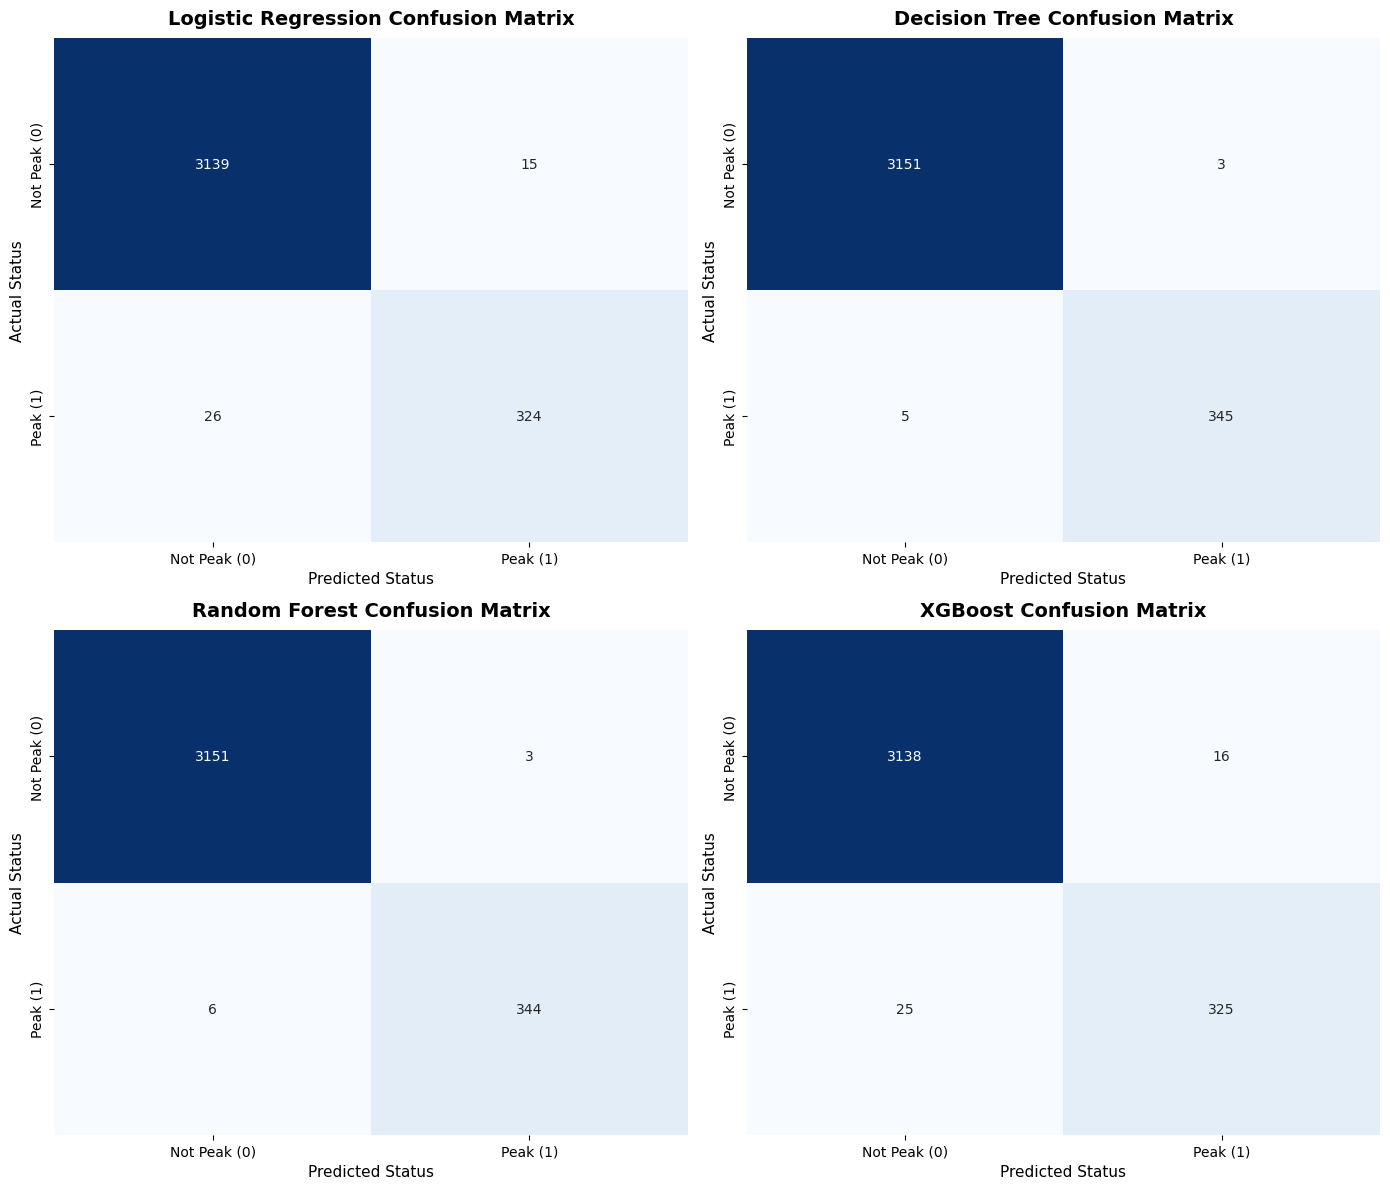

In [62]:
# confusion matrix heatmap shows how any peaks each model correctly caught vs how many it missed


trained_classifiers = {
    'Logistic Regression': logistic_regression,
    'Decision Tree': decisiontree_classifier,
    'Random Forest': randomforest_classifier,
    'XGBoost': xgb
}


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_classifiers.items()):
    ax = axes[idx]
    

    y_pred = model.predict(x_test)
    

    cm = confusion_matrix(y_test, y_pred)
    

    sn.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Not Peak (0)', 'Peak (1)'],
                yticklabels=['Not Peak (0)', 'Peak (1)'])
    

    ax.set_title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Actual Status', fontsize=11)
    ax.set_xlabel('Predicted Status', fontsize=11)

plt.tight_layout()
plt.show()